In [14]:
import pandas as pd
sales_data = {
    'Order_ID': [101,102,103,104,105,106,107,108,109,110,111,112],
    'Date': ['2025-01-05','2025-01-15','2025-02-10','2025-02-20',
             '2025-03-05','2025-03-18','2025-04-12','2025-04-25',
             '2025-05-08','2025-05-22','2025-06-10','2025-06-28'],
    'Product': ['Laptop','Mouse','Keyboard','Laptop',
                'Mouse','Monitor','Keyboard','Laptop',
                'Monitor','Mouse','Laptop','Keyboard'],
    'Quantity': [2,5,3,1,4,2,2,1,3,6,2,4],
    'Price': [50000,500,1000,50000,500,15000,1000,50000,15000,500,50000,1000]
}
df = pd.DataFrame(sales_data)
df

,Order_ID,Date,Product,Quantity,Price
0,101,2025-01-05,Laptop,2,50000
1,102,2025-01-15,Mouse,5,500
2,103,2025-02-10,Keyboard,3,1000
3,104,2025-02-20,Laptop,1,50000
4,105,2025-03-05,Mouse,4,500
5,106,2025-03-18,Monitor,2,15000
6,107,2025-04-12,Keyboard,2,1000
7,108,2025-04-25,Laptop,1,50000
8,109,2025-05-08,Monitor,3,15000
9,110,2025-05-22,Mouse,6,500


In [15]:
df.loc[3, 'Price'] = None
df.loc[7, 'Quantity'] = None
df

,Order_ID,Date,Product,Quantity,Price
0,101,2025-01-05,Laptop,2.0,50000.0
1,102,2025-01-15,Mouse,5.0,500.0
2,103,2025-02-10,Keyboard,3.0,1000.0
3,104,2025-02-20,Laptop,1.0,NaN
4,105,2025-03-05,Mouse,4.0,500.0
5,106,2025-03-18,Monitor,2.0,15000.0
6,107,2025-04-12,Keyboard,2.0,1000.0
7,108,2025-04-25,Laptop,NaN,50000.0
8,109,2025-05-08,Monitor,3.0,15000.0
9,110,2025-05-22,Mouse,6.0,500.0


In [16]:
df = pd.concat([df, df.iloc[[2]]], ignore_index=True)

df

,Order_ID,Date,Product,Quantity,Price
0,101,2025-01-05,Laptop,2.0,50000.0
1,102,2025-01-15,Mouse,5.0,500.0
2,103,2025-02-10,Keyboard,3.0,1000.0
3,104,2025-02-20,Laptop,1.0,NaN
4,105,2025-03-05,Mouse,4.0,500.0
5,106,2025-03-18,Monitor,2.0,15000.0
6,107,2025-04-12,Keyboard,2.0,1000.0
7,108,2025-04-25,Laptop,NaN,50000.0
8,109,2025-05-08,Monitor,3.0,15000.0
9,110,2025-05-22,Mouse,6.0,500.0


In [17]:
print(df.isnull().sum())

Order_ID    0
Date        0
Product     0
Quantity    1
Price       1
dtype: int64


In [18]:
df.fillna(0, inplace=True)
df

,Order_ID,Date,Product,Quantity,Price
0,101,2025-01-05,Laptop,2.0,50000.0
1,102,2025-01-15,Mouse,5.0,500.0
2,103,2025-02-10,Keyboard,3.0,1000.0
3,104,2025-02-20,Laptop,1.0,0.0
4,105,2025-03-05,Mouse,4.0,500.0
5,106,2025-03-18,Monitor,2.0,15000.0
6,107,2025-04-12,Keyboard,2.0,1000.0
7,108,2025-04-25,Laptop,0.0,50000.0
8,109,2025-05-08,Monitor,3.0,15000.0
9,110,2025-05-22,Mouse,6.0,500.0


In [19]:
df.drop_duplicates(inplace=True)
df

,Order_ID,Date,Product,Quantity,Price
0,101,2025-01-05,Laptop,2.0,50000.0
1,102,2025-01-15,Mouse,5.0,500.0
2,103,2025-02-10,Keyboard,3.0,1000.0
3,104,2025-02-20,Laptop,1.0,0.0
4,105,2025-03-05,Mouse,4.0,500.0
5,106,2025-03-18,Monitor,2.0,15000.0
6,107,2025-04-12,Keyboard,2.0,1000.0
7,108,2025-04-25,Laptop,0.0,50000.0
8,109,2025-05-08,Monitor,3.0,15000.0
9,110,2025-05-22,Mouse,6.0,500.0


In [20]:
df['Revenue'] = df['Quantity'] * df['Price']

df.head()

,Order_ID,Date,Product,Quantity,Price,Revenue
0,101,2025-01-05,Laptop,2.0,50000.0,100000.0
1,102,2025-01-15,Mouse,5.0,500.0,2500.0
2,103,2025-02-10,Keyboard,3.0,1000.0,3000.0
3,104,2025-02-20,Laptop,1.0,0.0,0.0
4,105,2025-03-05,Mouse,4.0,500.0,2000.0


In [21]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

print(top_products)

Product
Laptop      200000.0
Monitor      75000.0
Keyboard      9000.0
Mouse         7500.0
Name: Revenue, dtype: float64


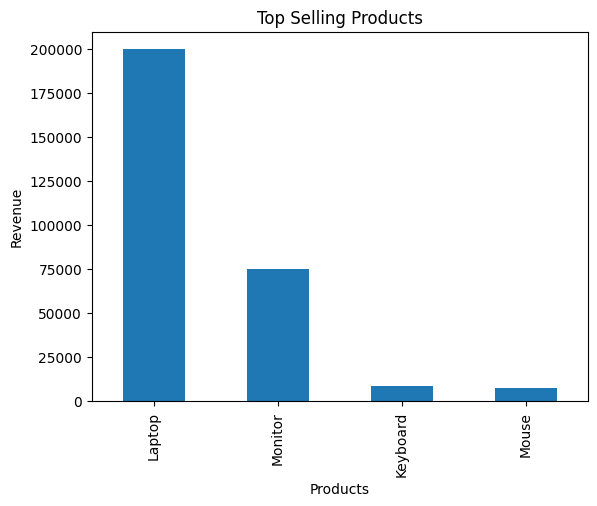

In [22]:
import matplotlib.pyplot as plt
top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.xlabel("Products")
plt.ylabel("Revenue")
plt.show()

In [23]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month_name()

monthly_sales = df.groupby('Month')['Revenue'].sum()

print(monthly_sales)

Month
April         2000.0
February      3000.0
January     102500.0
June        104000.0
March        32000.0
May          48000.0
Name: Revenue, dtype: float64


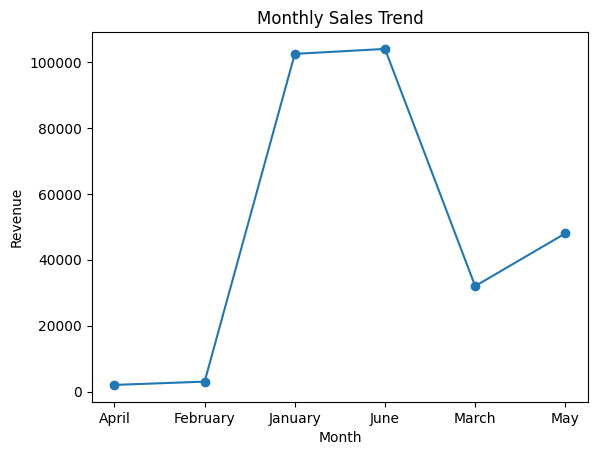

In [24]:
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [25]:
total_revenue = df['Revenue'].sum()
total_orders = df['Order_ID'].count()
total_products = df['Product'].nunique()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Unique Products:", total_products)

Total Revenue: 291500.0
Total Orders: 12
Unique Products: 4


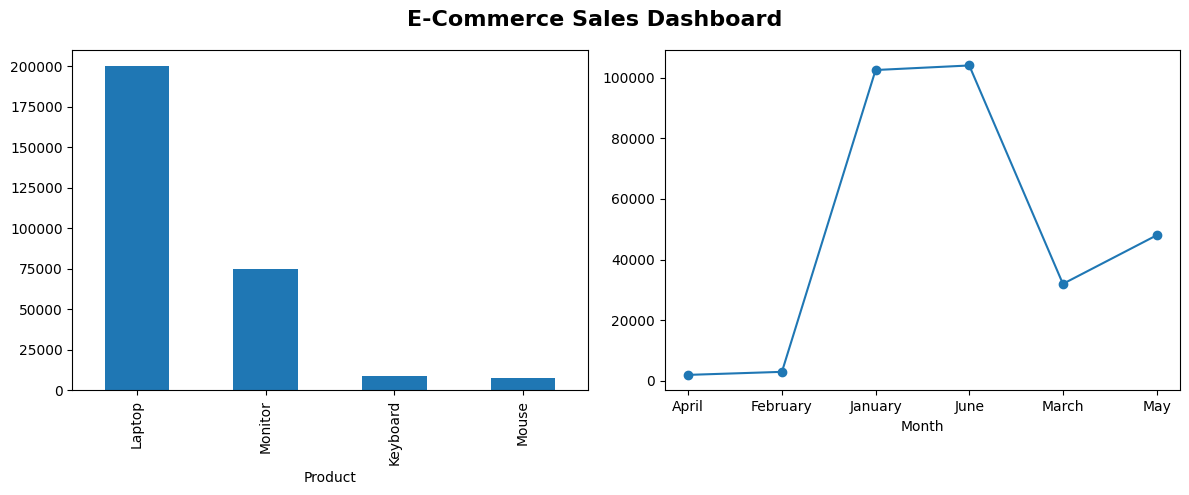

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

fig.suptitle(
    'E-Commerce Sales Dashboard',
    fontsize=16,
    fontweight='bold'
)

top_products.plot(kind='bar', ax=axes[0])
monthly_sales.plot(kind='line', marker='o', ax=axes[1])

plt.tight_layout()
plt.show()